# Question 2: Convergence of a walk on a discrete lattice

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
# Parameters & Given Info
t = 0
T = 1.75
N = 300
dt = T/N
sigma = 0.3
alpha = 0.4
X_init = 17
sim_counts = [1000, 10000, 100000]

In [3]:
p = 0.5*(1 + alpha/sigma*np.sqrt(dt))
exact_mean = X_init + alpha*T
exact_std = sigma*np.sqrt(T)

In [4]:
final_values_result = [] # Storage of the final values X(T) for each set of simulations

for n_sim in sim_counts:
    X = np.full(n_sim, X_init, dtype=float) # current value of X for every simulation (one lattice column only)
    t = 0
    n_steps = 0
    while t < T:
        t = t + dt
        n_steps = n_steps + 1
        U = np.random.uniform(0, 1, n_sim) # one uniform random number per simulation
        dX = np.where(U < p, sigma*np.sqrt(dt), -sigma*np.sqrt(dt)) # up with prob p, down with prob 1-p
        X = X + dX
    final_values_result.append(X)

    print('Number of simulations =', n_sim, ', steps taken =', n_steps)
    print('  Simulated mean =', np.mean(X), ', exact mean =', exact_mean)
    print('  Simulated std  =', np.std(X), ', exact std  =', exact_std)

Number of simulations = 1000 , steps taken = 300
  Simulated mean = 17.704296058557812 , exact mean = 17.7
  Simulated std  = 0.38644684226943826 , exact std  = 0.3968626966596886
Number of simulations = 10000 , steps taken = 300
  Simulated mean = 17.69855409121203 , exact mean = 17.7
  Simulated std  = 0.39333854584952743 , exact std  = 0.3968626966596886


Number of simulations = 100000 , steps taken = 300
  Simulated mean = 17.699781763240708 , exact mean = 17.7
  Simulated std  = 0.39425698070650683 , exact std  = 0.3968626966596886


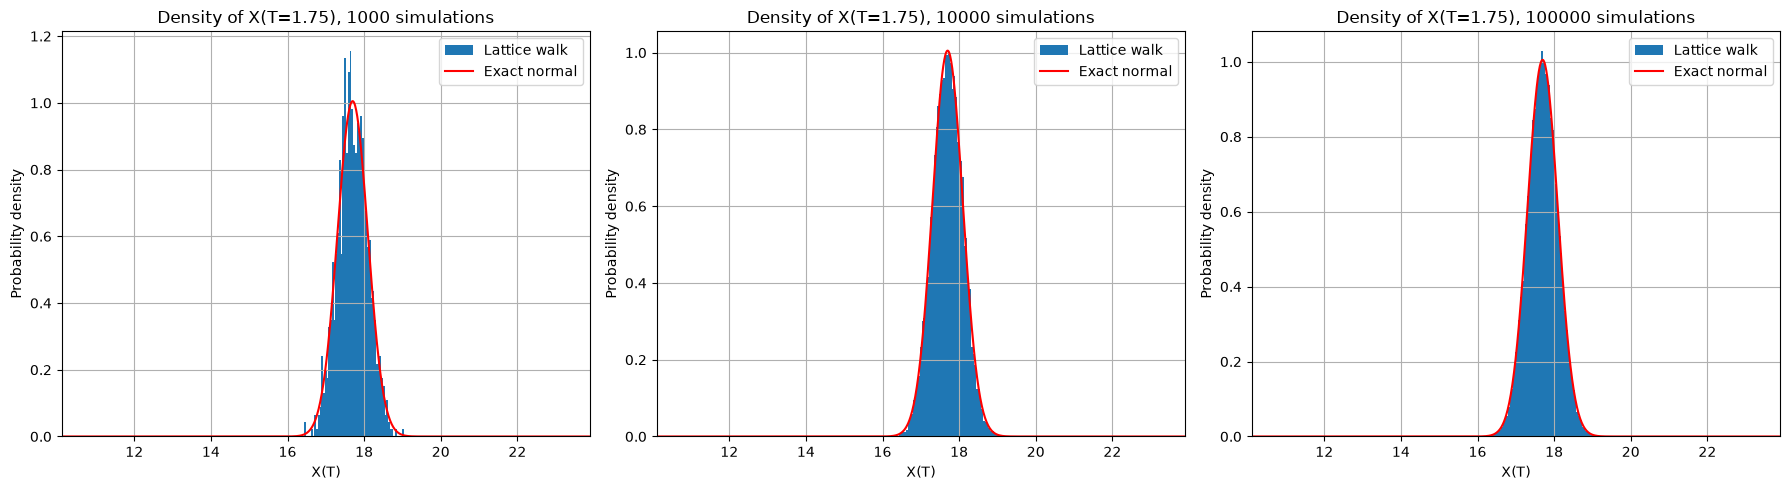

In [5]:
# Lattice nodes at timestep N, and N+1 bins with boundaries half-way between the nodes
j = np.arange(N + 1)
nodes = X_init + (2*j - N)*sigma*np.sqrt(dt)
bin_width = 2*sigma*np.sqrt(dt)
bin_edges = np.append(nodes - bin_width/2, nodes[-1] + bin_width/2)

# Exact normal density over the same range
x = np.linspace(bin_edges[0], bin_edges[-1], 1000)
exact_pdf = stats.norm.pdf(x, exact_mean, exact_std)

# Create the figure and subplots
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

for i in range(len(sim_counts)):
    # Plot the histogram (density=True divides each count by (total count * bin width))
    axs[i].hist(final_values_result[i], bins=bin_edges, density=True, label='Lattice walk')
    # Plot the exact normal distribution on top
    axs[i].plot(x, exact_pdf, color='red', label='Exact normal')

    # Set titles and labels
    axs[i].set_title(f'Density of X(T={T}), {sim_counts[i]} simulations')
    axs[i].set_xlabel('X(T)')
    axs[i].set_ylabel('Probability density')
    axs[i].set_xlim(bin_edges[0], bin_edges[-1])
    axs[i].legend()
    axs[i].grid(True)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

## Observations

In all three cases the simulated mean and standard deviation of $X(T)$ are close to the exact values $X_{init} + \alpha T = 17.7$ and $\sigma\sqrt{T} \approx 0.397$. As the number of simulations goes up from 1,000 to 100,000, the simulated values generally get closer to the exact values. The error shrinks roughly like $1/\sqrt{\text{number of simulations}}$, so each tenfold increase makes it about 3 times smaller. A single run can still be slightly better or worse by chance.

The histograms show the same thing. With 1,000 simulations the histogram is ragged: many bins hold only a few walks, so the bars jump up and down around the red curve. With 10,000 simulations the bell shape is clear. With 100,000 simulations the histogram lies almost exactly on the exact normal density.

More simulations only reduce the random sampling error. The lattice itself ($N = 300$) adds a small error of its own: $X_N$ can only land on the $N+1$ lattice nodes, and its standard deviation is $\sqrt{4p(1-p)}\,\sigma\sqrt{T} \approx 0.395$ instead of $0.397$. Only increasing $N$ (making $\Delta t$ smaller) removes that. Overall, the lattice walk agrees with the normal distribution of the SDE solution, and the agreement gets better as the number of simulations grows.